# ndlar_flow tutorial: Workshop Sep2026

Read a **flow file** (`.FLOW.hdf5`), and match simulated hits to MC truth.

| Part | Goal |
|---|---|
| 1 | open a file (two readers) |
| 2 | `data` / `ref` / `ref_region`, units |
| 3 | charge hits: three ways to read them, event display |
| 4 | MC truth: interactions / trajectories / segments |
| 5 | **backtracking: hit → segment → particle** |
| 6 | **example analysis: dE/dx from pixel hits** |
| 7 | producing a flow file yourself |

Run top to bottom — cells reuse earlier variables.

## 1 Setup and Installation

In [ ]:
%%capture
!pip install jupyter matplotlib h5py numpy legacy-cgi scienceplots
!cd ../.. && git clone https://github.com/DUNE/h5flow && pip install -e ./h5flow
!cd .. && pip install -e .

### WARNING: Restart kernel if you have to for the next step, sometimes packages wont be recognized immediately! ###

In [1]:
import sys
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
import h5flow
from h5flow.data import dereference

try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except Exception:
    pass
plt.rcParams.update({"figure.dpi": 130, "font.size": 9.5,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})

SEQ_CMAP   = "viridis"                    # magnitudes (Q, E, t)
ONE_SERIES = "#3e7fcd"                    # single-series histograms
CATEGORICAL = ["#3b6fb0", "#e06c15", "#00a06b", "#9457c9", "#c23a5e"]   # species
NEUTRAL     = "#8a8f98"                   # "other" / unmatched

print(f"numpy {np.__version__} | h5py {h5py.__version__} | "
      f"h5flow {getattr(h5flow, '__version__', 'unknown')}")

numpy 2.4.6 | h5py 3.16.0 | h5flow unknown


**Get a file:** MiniRun productions on the [NERSC portal](https://portal.nersc.gov/project/dune/data/2x2/simulation/),
or your own `larnd-sim` output run through the flow (Part 6).
Parts 4–5 need **simulation** (`mc_truth`); detector data stops at Part 3.

Two readers, two jobs:
* `h5py.File` — whole datasets as structured numpy arrays. File-wide distributions.
* `H5FlowDataManager` — follows the **references**: `mgr["charge/events", "charge/calib_final_hits", 7]`. Per-event reading.

In [2]:
MC = True   

if MC:
    FLOW_FILE = Path('/pscratch/sd/d/dunepro/mkramer/output/CentiRun7_1E20_RHC/run-ndlar-flow/CentiRun7_1E20_RHC.flow/FLOW/0000000/CentiRun7_1E20_RHC.flow.0000137.FLOW.hdf5')
else:
    FLOW_FILE = Path('/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2_dtg_nominal/flow/cosmics_bin14/mpd_run_run2data_rctl_949_p8_v0p2.FLOW.hdf5')

f_h5      = h5py.File(FLOW_FILE, "r")
f_manager = h5flow.data.H5FlowDataManager(str(FLOW_FILE), "r", mpi=False)

HAS_TRUTH = "mc_truth" in f_h5
HAS_LIGHT = "light" in f_h5

print(FLOW_FILE.name)
print("groups   :", list(f_h5.keys()))
print(f"mc_truth : {HAS_TRUTH}    light : {HAS_LIGHT}")

CentiRun7_1E20_RHC.flow.0000137.FLOW.hdf5
groups   : ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']
mc_truth : True    light : True


## 2 — File layout

`charge/` pixel readout - `light/` SiPMs - `combined/` cross-system (`t0`) -
`mc_truth/` simulation only - `geometry_info/`, `lar_info/`, `run_info/` metadata.

**The one structural idea.** Every dataset is a group:

```
charge/calib_final_hits/
├── data                       one row per hit
└── ref/charge/calib_prompt_hits/
    ├── ref                    (N,2) index pairs: (parent row, child row)
    └── ref_region             per parent row: which slice of `ref` to read
```

`H5FlowDataManager[...]` just walks that, in either direction. By hand:

```python
dereference(7, ref=..., region=..., data=...)
```

In [3]:
for group_name in f_h5.keys():
    print(f"{group_name}/ :", ", ".join(f_h5[group_name].keys()))

charge/ : calib_final_hits, calib_prompt_hits, events, ext_trigs, packets, packets_corr_ts, raw_events, raw_hits
combined/ : t0
geometry_info/ : anode_drift_coordinate, det_bounds, det_id, det_rel_pos, det_type, disabled_channels, disabled_chips, drift_dir, pixel_coordinates_2D, sipm_abs_pos, sipm_rel_pos, tile_id
lar_info/ : 
light/ : events, flash, sipm_hits, sum_hits, sum_tpc_hits, t_ns, wvfm
mc_truth/ : calib_final_hit_backtrack, calib_prompt_hit_backtrack, interactions, light_module0, light_module1, light_module2, light_module3, packet_fraction, segments, stack, trajectories
run_info/ : 


In [4]:
# the file's relationship map: which dereference chains are possible
refs = []
def _collect(name, obj):
    if isinstance(obj, h5py.Dataset) and name.endswith("/ref"):
        parent, child = name.split("/ref/", 1)
        refs.append((parent, child[:-len("/ref")], obj.shape[0]))
f_h5.visititems(_collect)

print(f"{'parent':34s} -> {'child':38s} {'pairs':>9s}")
for parent, child, n_pairs in sorted(refs):
    print(f"{parent:34s} -> {child:38s} {n_pairs:>9,}")

parent                             -> child                                      pairs
charge/calib_final_hits            -> mc_truth/calib_final_hit_backtrack       118,724
charge/calib_prompt_hits           -> charge/calib_final_hits                  118,724
charge/calib_prompt_hits           -> charge/packets                           152,651
charge/calib_prompt_hits           -> mc_truth/calib_prompt_hit_backtrack      152,651
charge/events                      -> charge/calib_final_hits                  118,724
charge/events                      -> charge/calib_prompt_hits                 152,651
charge/events                      -> charge/ext_trigs                             188
charge/events                      -> charge/raw_hits                          152,651
charge/events                      -> combined/t0                                  188
charge/events                      -> light/events                                 188
charge/ext_trigs                   -> light

### WARNING: There is a bug for the prompt->final matching present in files produced before September 14th, 2026 ###

## Hit reconstruction in flow ##
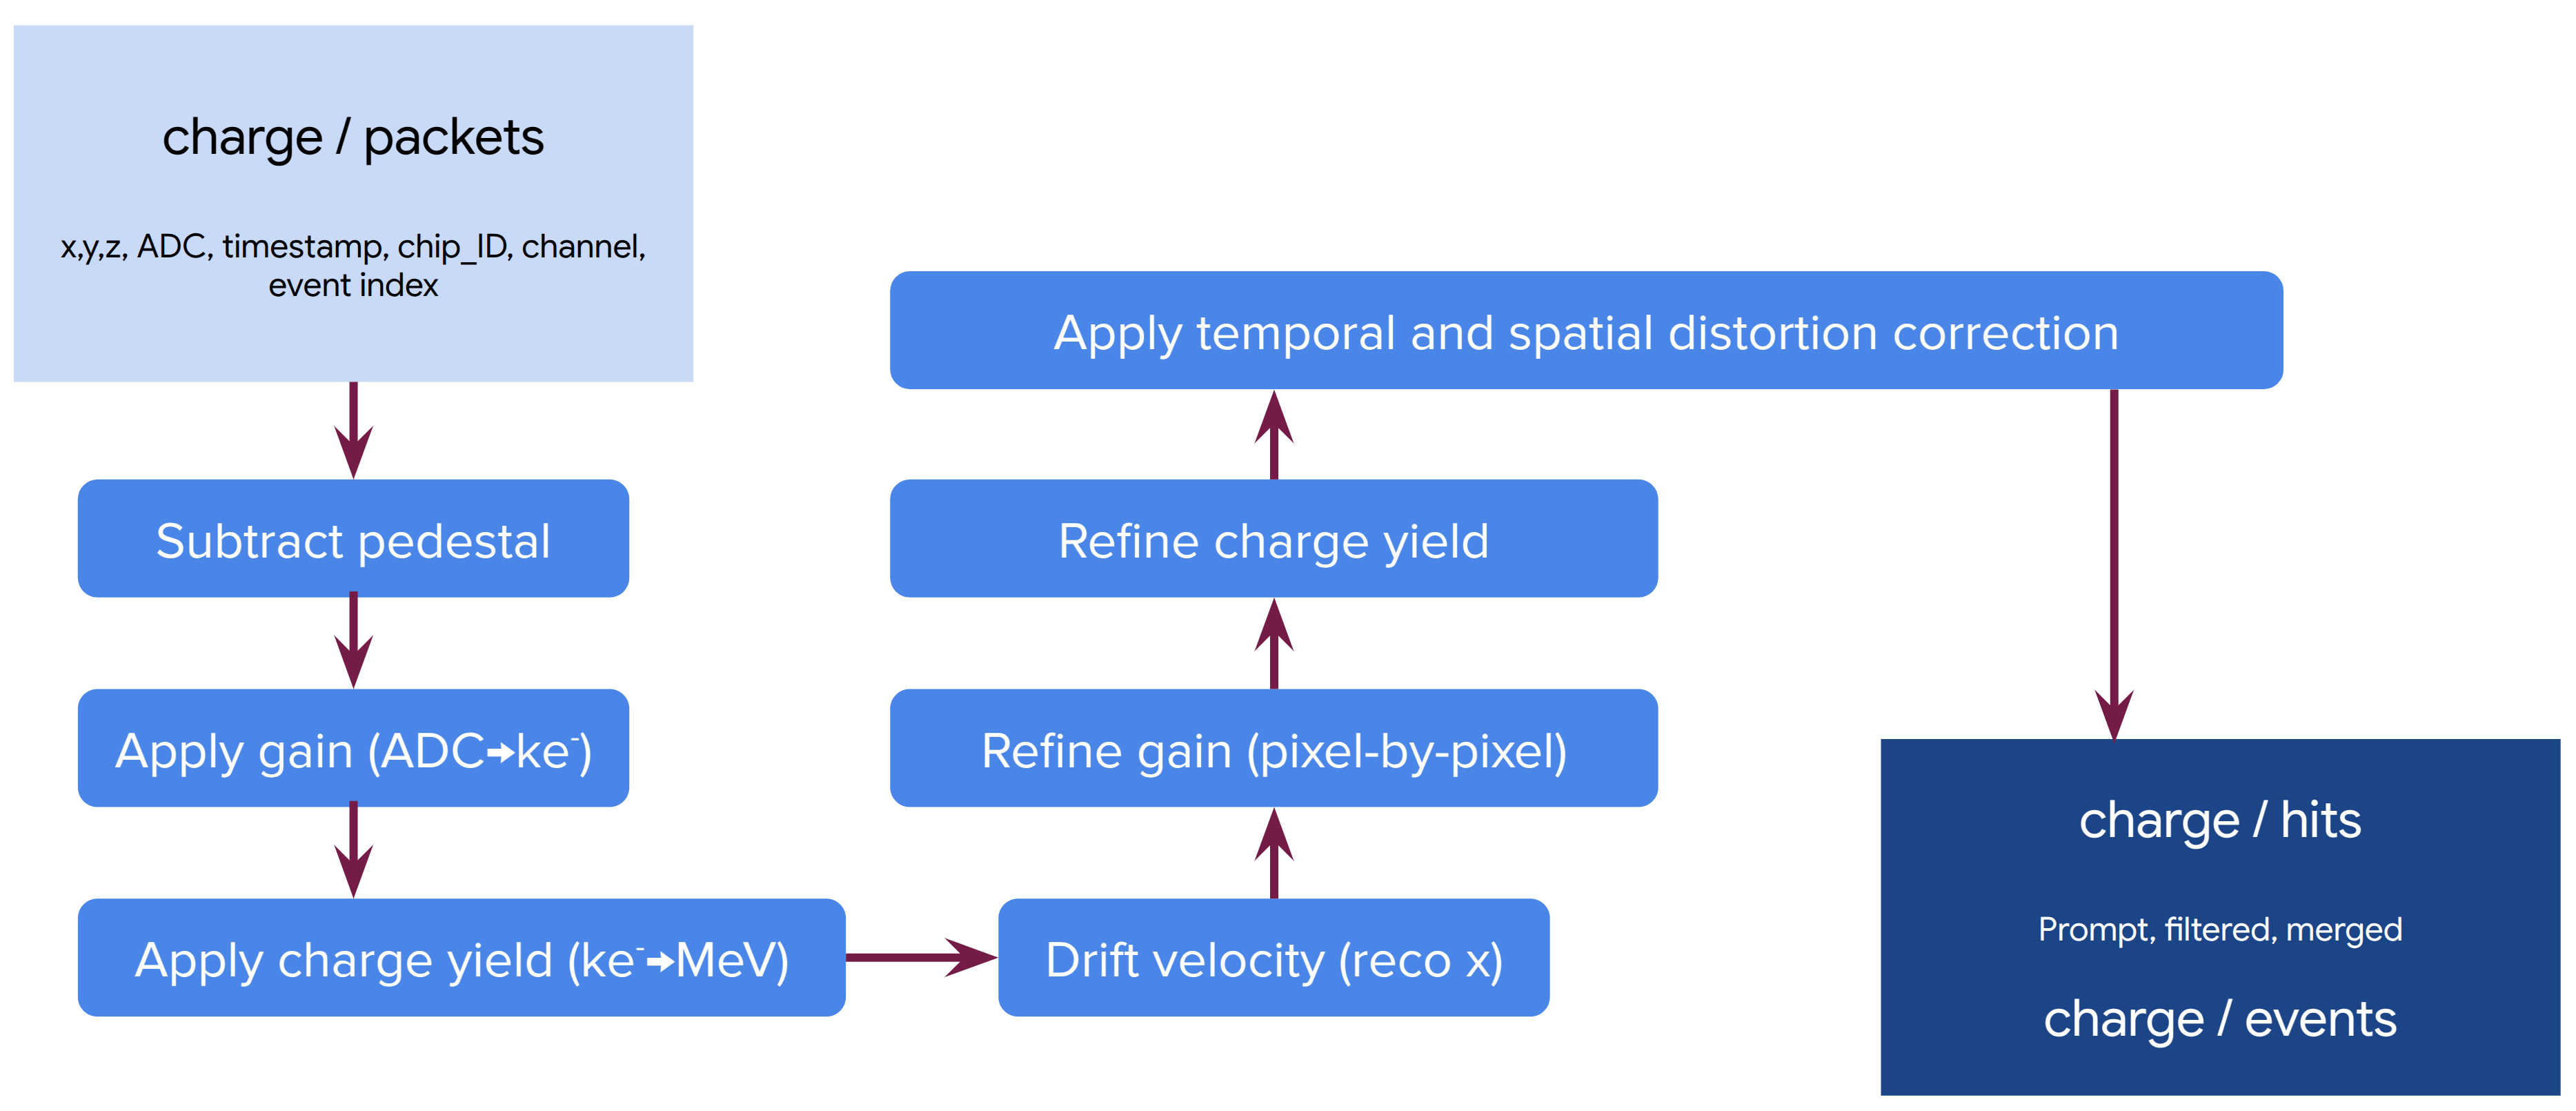

In [5]:
def fields_of(*paths):
    """Shape + field names of a `.../data` array."""
    for path in paths:
        dset = f_h5[path]
        print(f"{path}   {dset.shape}")
        if dset.dtype.names:
            print("    ", ", ".join(dset.dtype.names), "\n")

fields_of("charge/events/data",
          "charge/calib_prompt_hits/data",
          "charge/calib_final_hits/data")

charge/events/data   (188,)
     id, nhit, ADC, ts_start, ts_end, n_ext_trigs, unix_ts, unix_ts_usec 

charge/calib_prompt_hits/data   (152651,)
     id, x, y, z, t_drift, ts_pps, io_group, io_channel, chip_id, channel_id, Q_raw, Q, E, is_disabled 

charge/calib_final_hits/data   (118724,)
     id, x, y, z, t_drift, ts_pps, io_group, io_channel, chip_id, channel_id, Q_raw, Q, E, is_disabled 



### Coordinates and units — check before plotting

**x = drift**, **y = vertical**, **z = beam**.

| Quantity | Unit |
|---|---|
| `x,y,z` (hits, segments, trajectories, vertices) | cm |
| `Q`, `Q_raw` | ke⁻ |
| `E` (hits) | MeV |
| `dE`, `dEdx`, `dx` (segments) | MeV, MeV/cm, cm |
| `t_drift`, `ts_pps`, `ts_start` | CRS ticks of 0.1 µs |
| `t_ns` (light) | ns · one `wvfm` sample = 16 ns |
| `t_vert`, `t_event` | µs |

Hits and truth share a frame **within** a file — not across productions. Sanity-check every new sample:

In [6]:
hits = f_h5["charge/calib_final_hits/data"]
print(f"{len(hits):,} final hits\n")
for axis in "xyz":
    v = hits[axis]
    print(f"  {axis}  [{v.min():8.1f}, {v.max():8.1f}] cm   extent {v.max()-v.min():7.1f}")
print()
for field, unit in (("Q", "ke-"), ("E", "MeV"), ("t_drift", "ticks")):
    v = hits[field]
    print(f"  {field:8s} median {np.median(v):9.3f}  range [{v.min():.3f}, {v.max():.3f}] {unit}")

118,724 final hits

  x  [   -63.8,     63.8] cm   extent   127.5
  y  [   -61.9,     61.9] cm   extent   123.8
  z  [   -64.3,     64.3] cm   extent   128.7

  Q        median    14.927  range [1.145, 214.909] ke-
  E        median     0.526  range [0.039, 7.850] MeV
  t_drift  median   946.000  range [21.000, 2067.000] ticks


## 3 Charge data

```
charge/packets            raw LArPix words (type 0 = data, 7 = trigger)
   -> charge/raw_hits            + pixel position
   -> charge/calib_prompt_hits   ADC->Q, t_drift->x.  ONE PER PACKET = the measurement
   -> charge/calib_final_hits    merged neighbours.   THE ANALYSIS PRODUCT
charge/events   one trigger/readout window        combined/t0   event time
```

In [7]:
for path in ("charge/raw_events", "charge/events", "charge/ext_trigs", "charge/packets",
             "charge/raw_hits", "charge/calib_prompt_hits", "charge/calib_final_hits",
             "combined/t0"):
    if f"{path}/data" in f_h5:
        print(f"  {path:32s} {len(f_h5[f'{path}/data']):>12,}")

n_prompt = len(f_h5["charge/calib_prompt_hits/data"])
n_final  = len(f_h5["charge/calib_final_hits/data"])
print(f"\n  filtering: {n_final/n_prompt:.1%} as many final hits as prompt hits")

  charge/raw_events                         188
  charge/events                             188
  charge/ext_trigs                          188
  charge/packets                        304,313
  charge/raw_hits                       152,651
  charge/calib_prompt_hits              152,651
  charge/calib_final_hits               118,724
  combined/t0                               188

  filtering: 77.8% as many final hits as prompt hits


188 events; fields: id, nhit, ADC, ts_start, ts_end, n_ext_trigs, unix_ts, unix_ts_usec
    id=0      nhit=412     ts_start=0.0
    id=1      nhit=382     ts_start=2000000.0
    id=2      nhit=598     ts_start=4000000.0


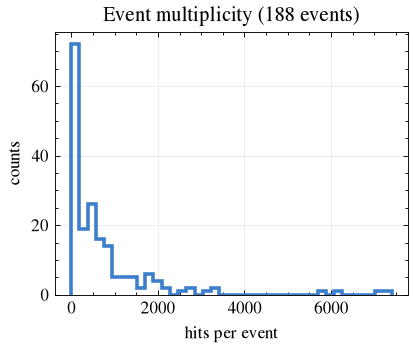

In [8]:
# events table + hit multiplicity
events = f_h5["charge/events/data"][:]
print(f"{len(events):,} events; fields: {', '.join(events.dtype.names)}")
for event in events[:3]:
    print(f"    id={event['id']:<6} nhit={event['nhit']:<7} ts_start={event['ts_start']}")

nhit = events["nhit"].astype(float)
fig, ax = plt.subplots()
ax.hist(nhit, bins=np.linspace(0, np.percentile(nhit, 99), 40),
        color=ONE_SERIES, histtype="step", lw=2)
ax.set(xlabel="hits per event", ylabel="counts", title=f"Event multiplicity ({len(events):,} events)")
plt.show()

### 3.1 Reading the hit datasets

They return the **same hits with the same numbers** — what differs is the packaging,
and what you can do next with it.

| | Call | You get back | Use it for |
|---|---|---|---|
| **(a)** | `f_h5["charge/calib_final_hits/data"][:]` | the **whole file**, one plain structured array, in file row order | file-wide distributions |
| **(b)** | `f_manager["charge/events", "charge/calib_final_hits", i]` | **one event's hit data**, as a padded, masked `(1, max_nhit)` array | a quick per-event look, an event display |
| **(c)** | `dereference(..., indices_only=True)` | **the row numbers** of one event's hits | everything else |

Why (c) exists: (a) knows nothing about events, and (b) hands you values but not
*where they live in the file*. Only a row number lets you pull the same object out of
another table — which is exactly what truth matching needs, because the Part-5
backtracking tables are row-aligned with the hits. §3.2 puts the three side by side.

#### (a) The whole file at once

one hit: {'id': np.uint32(0), 'x': np.float64(3.2455049697539873), 'y': np.float64(-61.85430145263672), 'z': np.float64(38.15570068359375), 't_drift': np.float64(21.0), 'ts_pps': np.uint64(19), 'io_group': np.uint64(2), 'io_channel': np.uint64(25), 'chip_id': np.uint64(19), 'channel_id': np.uint64(63), 'Q_raw': np.float64(2.1987242572095758), 'Q': np.float64(2.1987242572095758), 'E': np.float64(0.07407016843554563), 'is_disabled': np.False_}


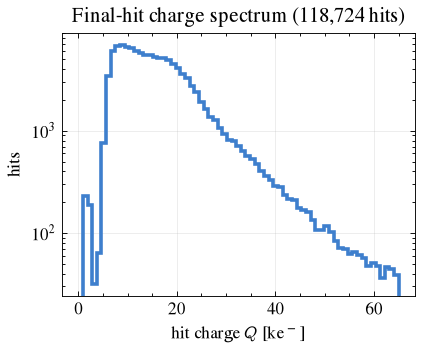

In [9]:
all_final_hits  = f_h5["charge/calib_final_hits/data"][:]
all_prompt_hits = f_h5["charge/calib_prompt_hits/data"][:]
print("one hit:", {k: all_final_hits[k][0] for k in all_final_hits.dtype.names})

charge = all_final_hits["Q"]
fig, ax = plt.subplots()
ax.hist(charge, bins=np.linspace(0, np.percentile(charge, 99.5), 70),
        color=ONE_SERIES, histtype="step", lw=2)
ax.set_yscale("log")
ax.set(xlabel=r"hit charge $Q$ [ke$^-$]", ylabel="hits",
       title=f"Final-hit charge spectrum ({len(charge):,} hits)")
plt.show()

#### (b) Per event, through the flow manager

`f_manager["charge/events", "charge/calib_final_hits", i]` walks `ref`/`ref_region` for you
and returns a **masked array** `(1, max_nhit)` — rectangular, so short events are padded.
**Always drop the mask before plotting**, or the fill values show up as a spike.

In [10]:
i_evt = 30

event_hits_masked = f_manager["charge/events", "charge/calib_final_hits", i_evt]
row = event_hits_masked[0]
is_real = ~np.ma.getmaskarray(row)["id"]      # getmaskarray: works when nothing is masked
event_hits = row[is_real]

print(f"shape {event_hits_masked.shape}  ->  {is_real.sum():,} real hits, "
      f"{(~is_real).sum():,} padding")
print(f"total charge {event_hits['Q'].sum():.1f} ke-")

shape (1, 1065)  ->  1,065 real hits, 0 padding
total charge 15692.7 ke-


#### (c) Dereference (row indices)

`dereference(..., indices_only=True)` returns row numbers instead of values. Those row
numbers are the currency: they index `data` *and* every row-aligned companion table
(Part 5). **`id` is not the row index** — the print below makes that concrete.

In [11]:
def event_rows(i_event, child, parent="charge/events"):
    """Row indices in <child>/data belonging to event i_event (padding removed)."""
    group = f_h5[f"{parent}/ref/{child}"]
    indices = dereference(i_event, ref=group["ref"], region=group["ref_region"],
                          ref_direction=(0, 1), indices_only=True)[0]
    return np.asarray(indices[~np.ma.getmaskarray(indices)], dtype=np.int64)


final_rows  = event_rows(i_evt, "charge/calib_final_hits")
prompt_rows = event_rows(i_evt, "charge/calib_prompt_hits")

final_hits_ev  = all_final_hits[final_rows]
prompt_hits_ev = all_prompt_hits[prompt_rows]

print(f"event {i_evt}: {len(final_rows)} final rows {final_rows[:6]}, "
      f"{len(prompt_rows)} prompt rows")
print(f"  their 'id' values: {all_final_hits['id'][final_rows][:6]}   <- NOT the row numbers")
print("  agrees with the manager read:",
      np.allclose(np.sort(final_hits_ev["z"]), np.sort(np.asarray(event_hits["z"]))))

event 30: 1065 final rows [30489 30490 30491 30492 30493 30494], 1419 prompt rows
  their 'id' values: [39500 39503 39504 39505 39509 39510]   <- NOT the row numbers
  agrees with the manager read: True


### 3.2 Event display
#### Also see larnddisplay.lbl.gov
Import event display and fix some depreciation

In [12]:
import os, sys, types

# --- fix pkg_resources: recent setuptools no longer ships it, so provide a
#     minimal shim backed by importlib.metadata (what the module actually needs) ---
try:
    import pkg_resources                      # noqa: F401
except Exception:
    import importlib.metadata as _md
    _pr = types.ModuleType("pkg_resources")
    class _Dist:
        __slots__ = ("key",)
        def __init__(self, k): self.key = k
    # real installed dists, plus the names lar2x2_evd checks for (avoids redundant pip calls)
    _names = {(d.metadata["Name"] or "") for d in _md.distributions() if d.metadata.get("Name")}
    _names |= {"numpy","pandas","sqlalchemy","h5py","cmasher","IPython","PyMuPDF",
               "matplotlib","pillow","uproot","h5flow","ipywidgets"}
    _pr.working_set = [_Dist(n) for n in _names]
    sys.modules["pkg_resources"] = _pr

# --- locate the ndlar_flow checkout (walk up from this notebook) and add to path ---
_root = os.getcwd()
while _root != "/" and not os.path.isdir(os.path.join(_root, "event_display", "LAr_evd")):
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "event_display", "LAr_evd")), \
    "Run this notebook from inside your ndlar_flow checkout (or set _root manually)."
sys.path[:0] = [_root, os.path.join(_root, "event_display", "LAr_evd")]

from lar2x2_evd import *
plt.ion()

Hello


Number of external triggers in this event: 1
Event 30 is NOT a beam trigger event


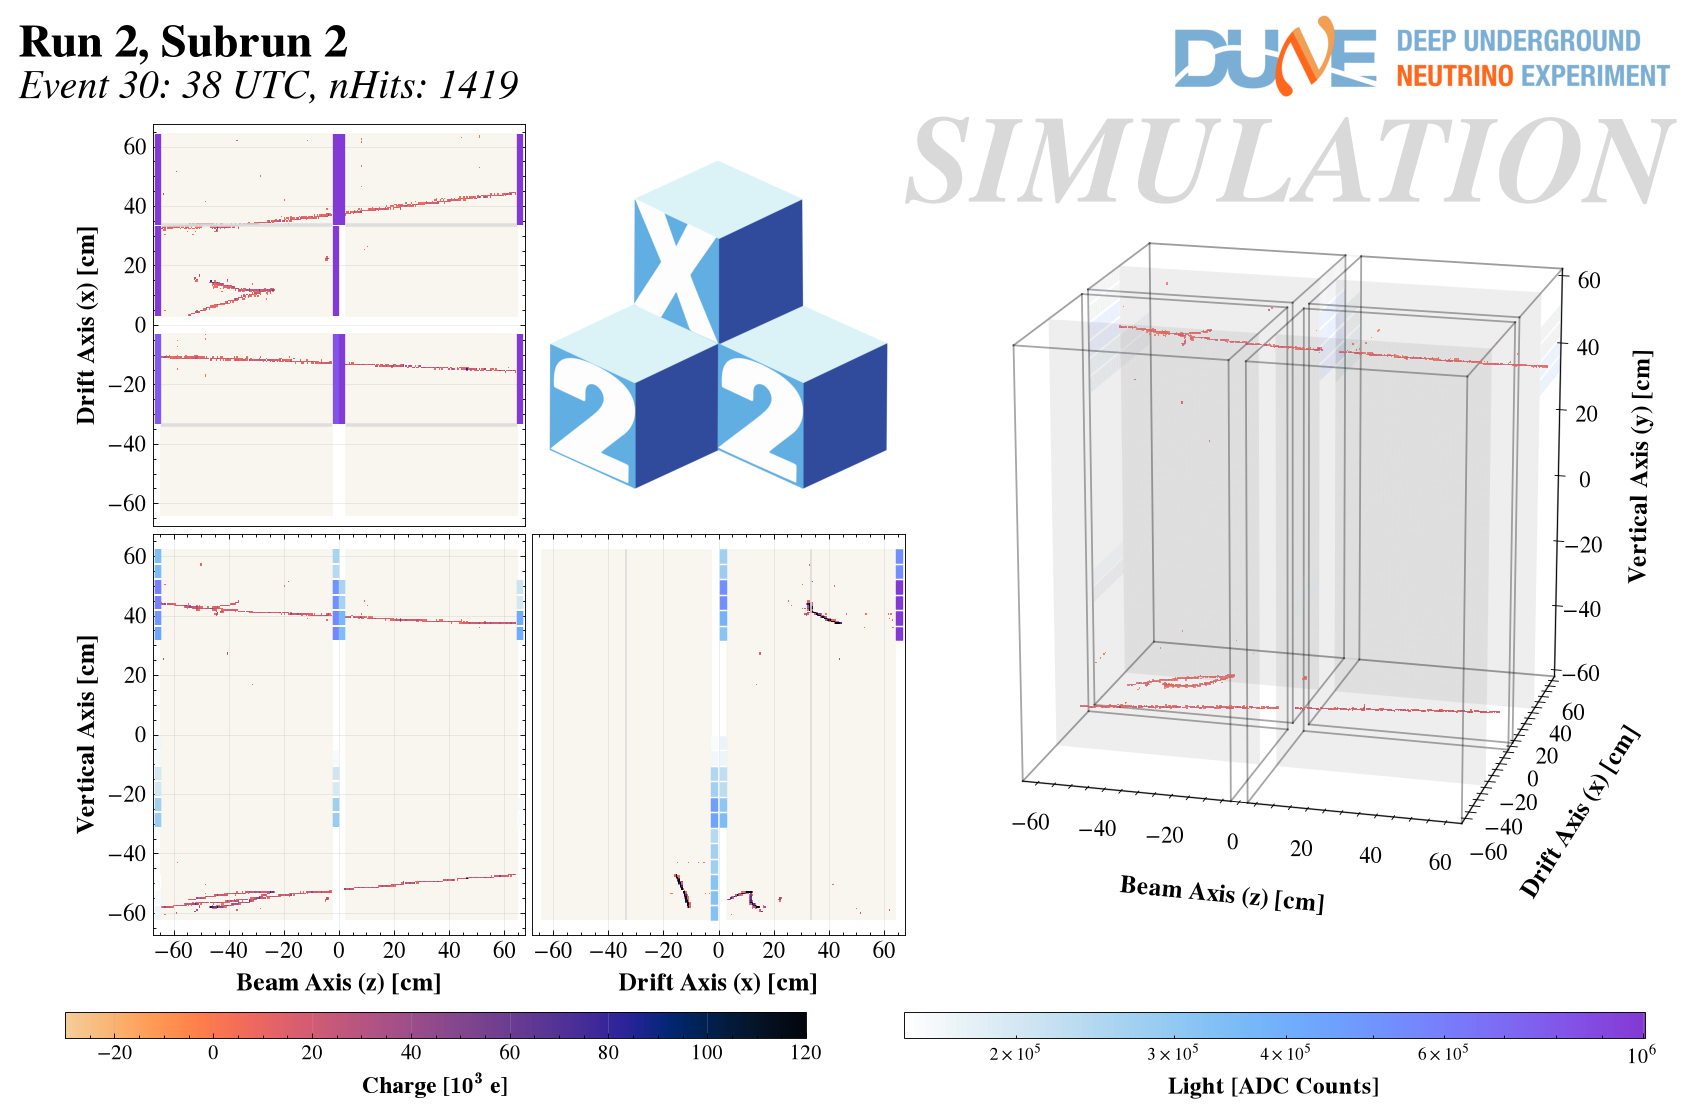

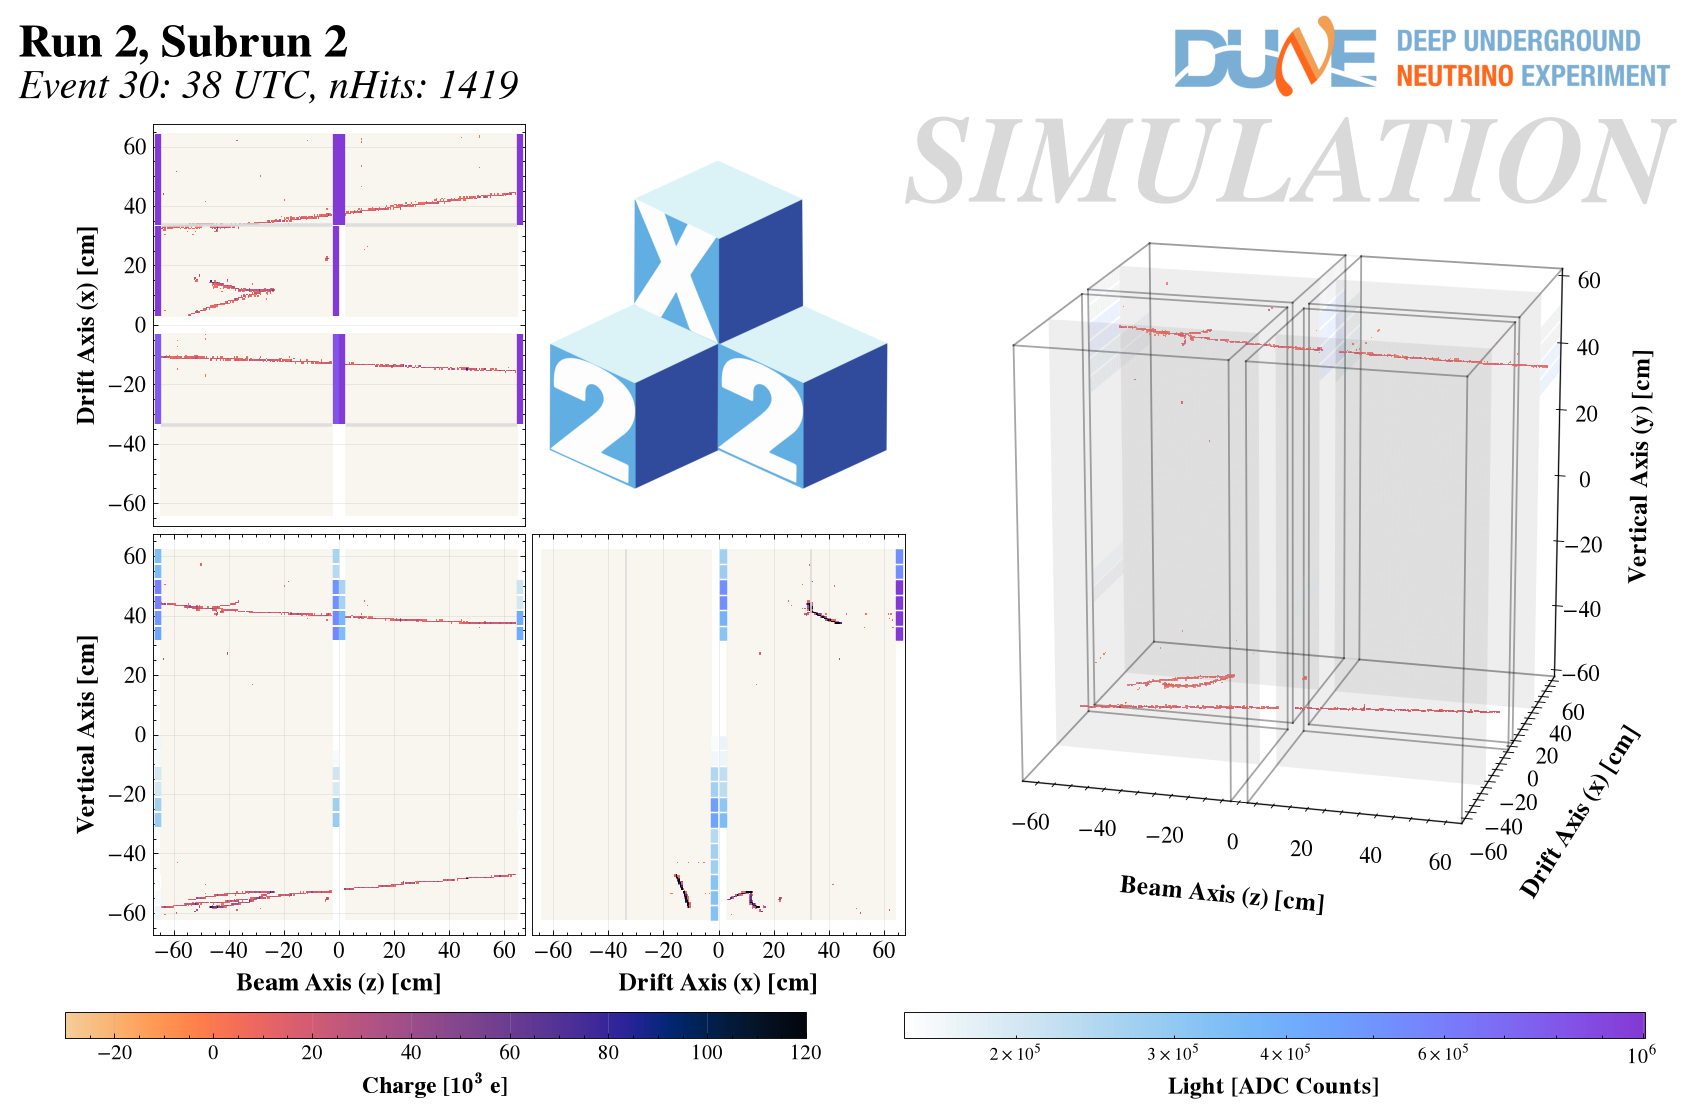

In [13]:
d = "/pscratch/sd/d/dunepro/mkramer/output/CentiRun7_1E20_RHC/run-ndlar-flow/CentiRun7_1E20_RHC.flow/FLOW/0000000/"
f = "CentiRun7_1E20_RHC.flow.0000137.FLOW.hdf5"

evd = LArEventDisplay(filedir=d, filename=f,     nhits_min=0, ntrigs=0,
    show_light=True,            # set True only if the file has light data
    show_colorbars=True,
    filepath_mx2=None,           # a MINERvA .root file, or None
)
evd.display_event(30)
plt.gcf()                # (in a notebook the figure shows automatically)

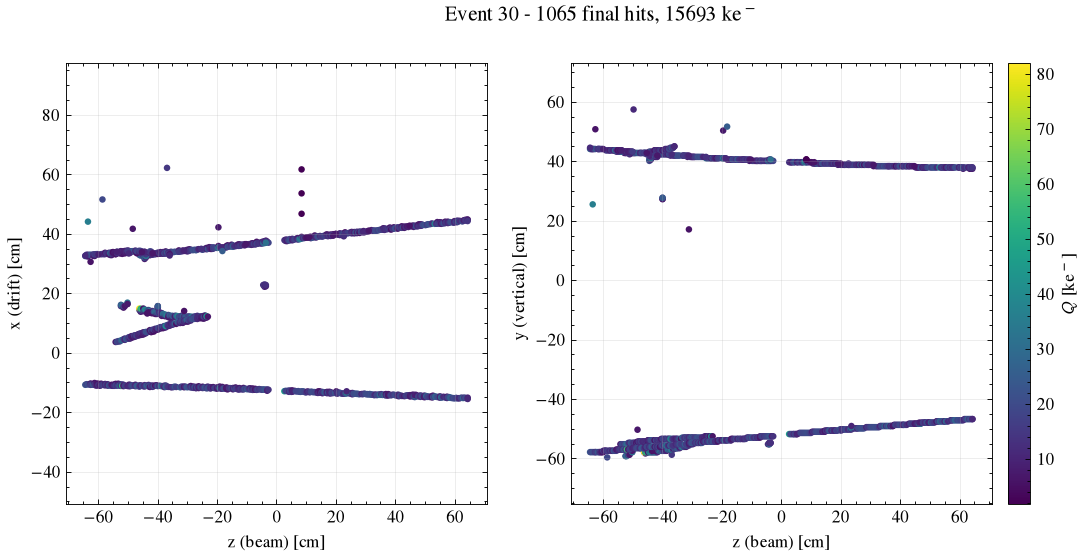

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for ax, (vertical, vlabel) in zip(axes, [("x", "x (drift) [cm]"), ("y", "y (vertical) [cm]")]):
    points = ax.scatter(final_hits_ev["z"], final_hits_ev[vertical], c=final_hits_ev["Q"],
                        s=13, cmap=SEQ_CMAP, edgecolors="none")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set(xlabel="z (beam) [cm]", ylabel=vlabel)
fig.colorbar(points, ax=axes, pad=0.015).set_label(r"$Q$ [ke$^-$]")
plt.suptitle(f"Event {i_evt} - {len(final_hits_ev)} final hits, {final_hits_ev['Q'].sum():.0f} ke$^-$")
plt.show()

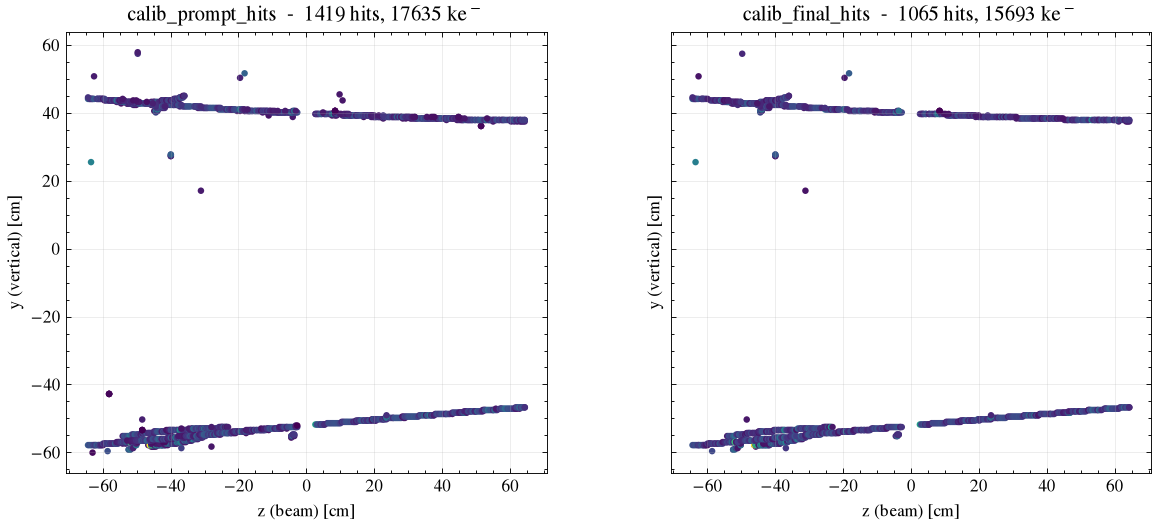

In [15]:
# what the filtering step did: prompt vs final, same event
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharex=True, sharey=True)
for ax, hits_ev, name in ((axes[0], prompt_hits_ev, "calib_prompt_hits"),
                          (axes[1], final_hits_ev,  "calib_final_hits")):
    ax.scatter(hits_ev["z"], hits_ev["y"], c=hits_ev["Q"], s=13, cmap=SEQ_CMAP, edgecolors="none")
    ax.set_aspect("equal", adjustable="box")
    ax.set(xlabel="z (beam) [cm]", ylabel="y (vertical) [cm]",
           title=f"{name}  -  {len(hits_ev)} hits, {hits_ev['Q'].sum():.0f} ke$^-$")
plt.show()

## 4 Accessing MC truth  *(simulation files only)*

| Dataset | One row is | Answers |
|---|---|---|
| `mc_truth/interactions` | a neutrino vertex (GENIE) | what event, where, Eν |
| `mc_truth/trajectories` | a particle (Geant4) | species, parent, energy |
| `mc_truth/segments` | an edep-sim step | where energy went, how much |

Nesting: interaction → trajectories → segments → hits

**Identifier scope — the classic bug:**

| Field | Unique within |
|---|---|
| `event_id` | file | yes |
| `segment_id` | **file** | **yes** |
| `file_traj_id` | **file** | **yes** |
| `vertex_id` | an event | only with `event_id` |
| `traj_id` | **one interaction** | **no**|

In [16]:
interactions = trajectories = segments = None
if HAS_TRUTH:
    interactions = f_h5["mc_truth/interactions/data"][:]
    trajectories = f_h5["mc_truth/trajectories/data"][:]
    segments     = f_h5["mc_truth/segments/data"][:]
    for name, table in (("interactions", interactions), ("trajectories", trajectories),
                        ("segments", segments)):
        print(f"mc_truth/{name}: {len(table):,} rows\n    {', '.join(table.dtype.names)}\n")

    print("segment_id   unique in file:", len(np.unique(segments["segment_id"])) == len(segments))
    print("file_traj_id unique in file:", len(np.unique(trajectories["file_traj_id"])) == len(trajectories))
    print("traj_id      unique in file:", len(np.unique(trajectories["traj_id"])) == len(trajectories))

    pair   = np.stack([trajectories["event_id"], trajectories["traj_id"]], axis=1)
    triple = np.stack([trajectories["event_id"], trajectories["vertex_id"],
                       trajectories["traj_id"]], axis=1)
    print("(event_id, traj_id)             unique:",
          len(np.unique(pair, axis=0)) == len(trajectories),
          "  <- False = several interactions per spill")
    print("(event_id, vertex_id, traj_id)  unique:",
          len(np.unique(triple, axis=0)) == len(trajectories))
    print(f"interactions per spill: {len(interactions) / len(np.unique(interactions['event_id'])):.1f}")
else:
    print("[skipped] no mc_truth - this is detector data. Parts 4-5 need simulation.")

mc_truth/interactions: 719 rows
    t_event, event_id, f2, vertex_id, x_vert, y_vert, z_vert, f7, t_vert, target, reaction, isCC, isQES, isMEC, isRES, isDIS, isCOH, f17, Enu, nu_4mom, nu_pdg, Elep, lep_mom, lep_ang, lep_pdg, q0, q3, Q2, x, y, f30

mc_truth/trajectories: 114,242 rows
    event_id, vertex_id, traj_id, file_traj_id, parent_id, primary, E_start, pxyz_start, xyz_start, t_start, E_end, pxyz_end, xyz_end, t_end, KE_start, KE_end, pdg_id, start_process, start_subprocess, end_process, end_subprocess, dist_travel

mc_truth/segments: 133,643 rows
    event_id, vertex_id, segment_id, z_end, traj_id, file_traj_id, tran_diff, z_start, x_end, y_end, n_electrons, pdg_id, x_start, y_start, t_start, t0_start, t0_end, t0, dx, long_diff, pixel_plane, t, t_end, dEdx, dE, dE_secondary, y, x, z, n_photons

segment_id   unique in file: True
file_traj_id unique in file: True
traj_id      unique in file: False
(event_id, traj_id)             unique: False   <- False = several interactions per s

### 4.1 Interactions

In [17]:
vertex_xyz = None
if HAS_TRUTH and len(interactions):
    fields = set(interactions.dtype.names)
    if {"x_vert", "y_vert", "z_vert"} <= fields:
        vertex_xyz = np.stack([interactions[f"{a}_vert"] for a in "xyz"], axis=1)
    elif "vertex" in fields:
        vertex_xyz = np.asarray(interactions["vertex"])
    if vertex_xyz is not None:
        for axis, name in enumerate("xyz"):
            print(f"  {name}_vert [{vertex_xyz[:, axis].min():8.1f}, {vertex_xyz[:, axis].max():8.1f}] cm")

    present = [f for f in ("Enu", "isCC", "reaction", "Elep", "nu_pdg", "target", "q2") if f in fields]
    print("\nneutrino kinematics fields:", present or "none (particle gun / cosmics)")

  x_vert [  -741.4,    706.5] cm
  y_vert [  -398.7,    973.2] cm
  z_vert [ -9747.1,    999.0] cm

neutrino kinematics fields: ['Enu', 'isCC', 'reaction', 'Elep', 'nu_pdg', 'target']


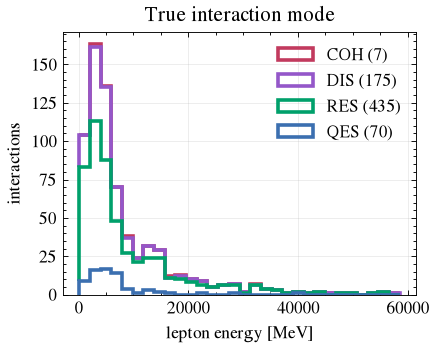

In [18]:
# interaction modes - neutrino samples only
REACTION_NAMES = {1: "QES", 2: "MEC", 3: "RES", 4: "DIS", 5: "COH"}

if HAS_TRUTH and {"reaction", "Elep"} <= set(interactions.dtype.names):
    series, labels_, colors = [], [], []
    for slot, (code, name) in enumerate(sorted(REACTION_NAMES.items())):
        selected = interactions[interactions["reaction"] == code]["Elep"]
        if len(selected):
            series.append(selected); labels_.append(f"{name} ({len(selected):,})")
            colors.append(CATEGORICAL[slot % len(CATEGORICAL)])
    fig, ax = plt.subplots()
    ax.hist(series, bins=30, stacked=True, histtype="step", lw=2, color=colors, label=labels_)
    ax.legend(frameon=False)
    ax.set(xlabel="lepton energy [MeV]", ylabel="interactions", title="True interaction mode")
    plt.show()
else:
    print("[skipped] no reaction/Elep in this sample.")

## 5 Truth backtracking from hits 

```
segments (dE, dx) --larnd-sim--> drift --> charge/packets   <-- truth attached HERE
      -> calib_prompt_hits -> calib_final_hits 
```

Many-to-many: one hit has **several** contributing segments, one segment feeds several hits.
So a hit's truth is a **weighted list, not a label** — that list is the backtracking table.

| Backtrack dataset | Row-aligned with |
|---|---|
| `mc_truth/calib_prompt_hit_backtrack` | `charge/calib_prompt_hits/data` |
| `mc_truth/calib_final_hit_backtrack`  | `charge/calib_final_hits/data` |

Fields (fixed-length, padded with `-1`/`0`):
`segment_ids`, `fraction` (share of **this hit's** charge), `file_traj_ids`,
`fraction_traj`, `event_ids`.

In [19]:
backtrack_final = backtrack_prompt = None
if HAS_TRUTH:
    backtrack_final  = f_h5["mc_truth/calib_final_hit_backtrack/data"][:]
    backtrack_prompt = f_h5["mc_truth/calib_prompt_hit_backtrack/data"][:]
    for field in backtrack_final.dtype.names:
        print(f"    {field:<16} {backtrack_final.dtype[field]}")

    print("\nrow-aligned with the hits:",
          len(backtrack_final) == len(all_final_hits),
          "/", len(backtrack_prompt) == len(all_prompt_hits))
    n_links = (backtrack_final["fraction"] > 0).sum(axis=1)

    event_ids        ('<i8', (1,))
    segment_ids      ('<i8', (20,))
    fraction         ('<f8', (20,))
    file_traj_ids    ('<i8', (20,))
    fraction_traj    ('<f8', (20,))

row-aligned with the hits: True / True


### 5.1 Lookups

Truth is joined on **identifier fields**, not on references: the backtrack tables store
`segment_id` *values*, so you have to look them up whatever references exist. (This file
does store `trajectories → segments`; some productions do not — check the map in §2.)

`make_lookup` sorts a key column once, then answers many queries at once; it also tells
you which keys it failed to find, rather than returning something plausible.

In [20]:
def make_lookup(keys):
    """values -> (row indices, found mask), via a sorted index. Works on any shape."""
    order = np.argsort(keys)
    sorted_keys = keys[order]
    def lookup(values):
        values = np.asarray(values)
        position = np.clip(np.searchsorted(sorted_keys, values), 0, len(sorted_keys) - 1)
        return order[position], sorted_keys[position] == values
    return lookup


def make_key_lookup(*key_columns):
    """Same, for a key made of several fields, packed into one integer."""
    strides = [np.int64(int(np.max(column)) + 1) for column in key_columns]
    def pack(columns):
        packed = np.zeros(np.shape(columns[0]), dtype=np.int64)
        for column, stride in zip(columns, strides):
            packed = packed * stride + np.asarray(column, dtype=np.int64)
        return packed
    inner = make_lookup(pack(key_columns))
    return lambda *values: inner(pack(values))


if HAS_TRUTH:
    # file-unique keys: these two are the ones to build an analysis on
    segment_lookup    = make_lookup(segments["segment_id"])
    trajectory_lookup = make_lookup(trajectories["file_traj_id"])
    trajectory_vertex_lookup = make_key_lookup(trajectories["event_id"],
                                               trajectories["vertex_id"],
                                               trajectories["traj_id"])
    interaction_lookup = make_key_lookup(interactions["event_id"],
                                         interactions["vertex_id"])
    print("lookups built.")

lookups built.


### 5.2 Obtain true MC interactions and particles inside a spill/event


In [21]:
PDG_NAMES = {11:"e-", -11:"e+", 12:"nu_e", -12:"anu_e", 13:"mu-", -13:"mu+",
             14:"nu_mu", -14:"anu_mu", 22:"gamma", 111:"pi0", 211:"pi+", -211:"pi-",
             321:"K+", -321:"K-", 130:"K0L", 310:"K0S", 2112:"n", 2212:"p",
             -2212:"pbar", 1000010020:"d", 1000020040:"alpha"}
pdg_name = lambda c: PDG_NAMES.get(int(c), f"pdg {int(c)}")

if HAS_TRUTH and len(final_rows):
    # --- backtrack once: dominant true segment per hit -> pdg + its interaction (vertex) ---
    bt   = backtrack_final[final_rows]
    frac = bt["fraction"]
    best = np.argmax(np.where(frac > 0, frac, -1.0), axis=1)
    seg_rows, seg_found = segment_lookup(bt["segment_ids"][np.arange(len(final_rows)), best])
    matched = seg_found & (frac > 0).any(axis=1)

    seg = segments[seg_rows]                                  # aligned to final_rows
    pdg = np.where(matched, seg["pdg_id"], 0)
    ev  = seg["event_id"]
    has_vtx = "vertex_id" in seg.dtype.names
    vtx = seg["vertex_id"] if has_vtx else np.zeros(len(seg), ev.dtype)

    ifields = set(interactions.dtype.names)
    REACTION_NAMES = {1: "QES", 2: "MEC", 3: "RES", 4: "DIS", 5: "COH"}

    def interaction_label(e, v):
        m = interactions["event_id"] == e
        if has_vtx and "vertex_id" in ifields:
            m &= interactions["vertex_id"] == v
        if not m.any():
            return "(no interaction row)"
        ixn, bits = interactions[m][0], []
        if "reaction" in ifields:
            bits.append(REACTION_NAMES.get(int(ixn["reaction"]), f"reaction {int(ixn['reaction'])}"))
        if "isCC" in ifields:   bits.append("CC" if ixn["isCC"] else "NC")
        if "nu_pdg" in ifields: bits.append(pdg_name(ixn["nu_pdg"]))
        if "Enu" in ifields:    bits.append(f"Enu={float(ixn['Enu']):.1f}")
        return "  ".join(bits) if bits else "(non-neutrino: cosmics / gun)"

    print(f"Event {i_evt}: {int(matched.sum())}/{len(final_rows)} hits matched")
    keys = np.stack([ev, vtx], axis=1)[matched]
    uniq, cnt = np.unique(keys, axis=0, return_counts=True)
    for (e, v), n in sorted(zip(map(tuple, uniq), cnt), key=lambda t: -t[1]):
        print(f"\n  vertex {v} (event_id {e}) — {interaction_label(e, v)}   [{n} hits]")
        sel = matched & (ev == e) & (vtx == v)
        codes, counts = np.unique(pdg[sel], return_counts=True)
        for code, count in sorted(zip(codes, counts), key=lambda t: -t[1]):
            print(f"      {pdg_name(code):>8s}  {count:5d} hits")
else:
    print("[skipped] needs mc_truth")


Event 30: 1065/1065 hits matched

  vertex 1371000057 (event_id 137032) — RES  CC  nu_mu  Enu=8479.5   [609 hits]
           mu-    366 hits
           pi-    213 hits
            e-     30 hits

  vertex 1000001371017426 (event_id 137032) — DIS  CC  anu_mu  Enu=5771.2   [454 hits]
           mu+    352 hits
            e-     96 hits
            e+      6 hits

  vertex 1000001371017160 (event_id 137032) — RES  CC  anu_mu  Enu=27345.6   [2 hits]
            e-      2 hits


### 5.3 Obtain PDG IDs of particles inside a spill/event

`truth_label_hits(hit_rows, backtrack_table)` → one truth label per hit.

In [22]:
if HAS_TRUTH and len(final_rows):
    # --- backtrack once: dominant true segment per hit -> pdg + its interaction (vertex) ---
    bt   = backtrack_final[final_rows]
    frac = bt["fraction"]
    best = np.argmax(np.where(frac > 0, frac, -1.0), axis=1)
    seg_rows, seg_found = segment_lookup(bt["segment_ids"][np.arange(len(final_rows)), best])
    matched = seg_found & (frac > 0).any(axis=1)

    seg = segments[seg_rows]                                  # aligned to final_rows
    pdg = np.where(matched, seg["pdg_id"], 0)
    ev  = seg["event_id"]
    has_vtx = "vertex_id" in seg.dtype.names
    vtx = seg["vertex_id"] if has_vtx else np.zeros(len(seg), ev.dtype)

    ifields = set(interactions.dtype.names)
    REACTION_NAMES = {1: "QES", 2: "MEC", 3: "RES", 4: "DIS", 5: "COH"}

    def interaction_label(e, v):
        m = interactions["event_id"] == e
        if has_vtx and "vertex_id" in ifields:
            m &= interactions["vertex_id"] == v
        if not m.any():
            return "(no interaction row)"
        ixn, bits = interactions[m][0], []
        if "reaction" in ifields:
            bits.append(REACTION_NAMES.get(int(ixn["reaction"]), f"reaction {int(ixn['reaction'])}"))
        if "isCC" in ifields:   bits.append("CC" if ixn["isCC"] else "NC")
        if "nu_pdg" in ifields: bits.append(pdg_name(ixn["nu_pdg"]))
        if "Enu" in ifields:    bits.append(f"Enu={float(ixn['Enu']):.1f}")
        return "  ".join(bits) if bits else "(non-neutrino: cosmics / gun)"

    print(f"Event {i_evt}: {int(matched.sum())}/{len(final_rows)} hits matched")
    keys = np.stack([ev, vtx], axis=1)[matched]
    uniq, cnt = np.unique(keys, axis=0, return_counts=True)
    for (e, v), n in sorted(zip(map(tuple, uniq), cnt), key=lambda t: -t[1]):
        print(f"\n  vertex {v} (event_id {e}) — {interaction_label(e, v)}   [{n} hits]")
        sel = matched & (ev == e) & (vtx == v)
        codes, counts = np.unique(pdg[sel], return_counts=True)
        for code, count in sorted(zip(codes, counts), key=lambda t: -t[1]):
            print(f"      {pdg_name(code):>8s}  {count:5d} hits")
else:
    print("[skipped] needs mc_truth")

Event 30: 1065/1065 hits matched

  vertex 1371000057 (event_id 137032) — RES  CC  nu_mu  Enu=8479.5   [609 hits]
           mu-    366 hits
           pi-    213 hits
            e-     30 hits

  vertex 1000001371017426 (event_id 137032) — DIS  CC  anu_mu  Enu=5771.2   [454 hits]
           mu+    352 hits
            e-     96 hits
            e+      6 hits

  vertex 1000001371017160 (event_id 137032) — RES  CC  anu_mu  Enu=27345.6   [2 hits]
            e-      2 hits


### 5.3 Event display coloured by **true species**, truth segments overlaid

Grey lines = what the simulation said happened. Dots = what was reconstructed, painted with
the identity of the particle that gave most of the charge. **If a hit does not sit on its
segment, the matching is wrong — and nothing raises.**

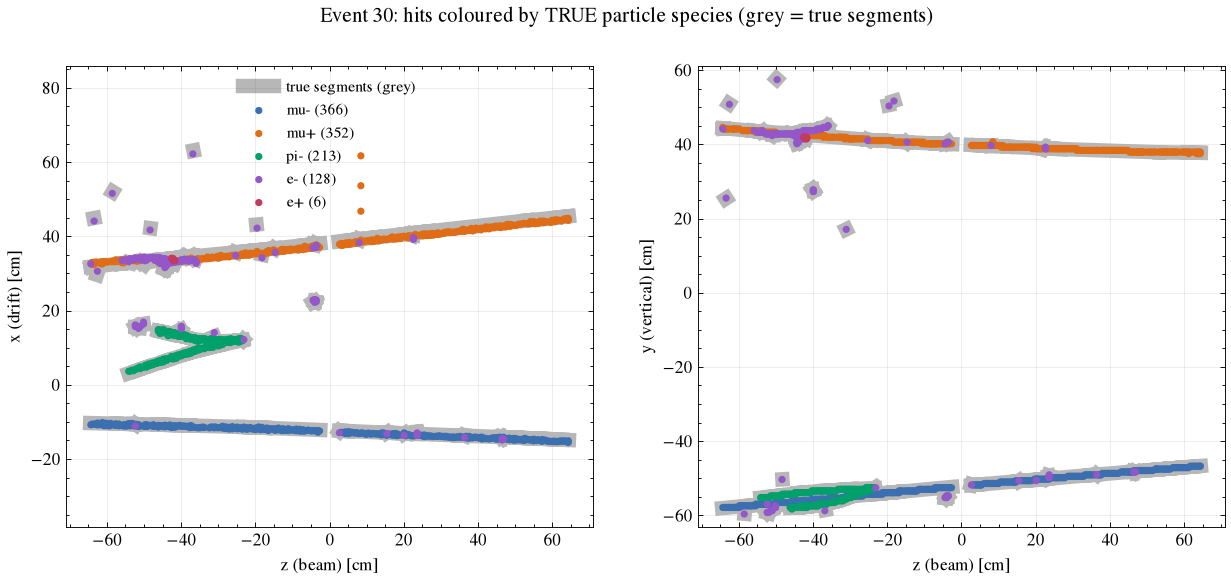

In [23]:
if HAS_TRUTH and len(final_hits_ev):
    # --- dominant true segment per hit (inline; largest charge-fraction slot) ---
    bt   = backtrack_final[final_rows]
    frac = bt["fraction"]
    best = np.argmax(np.where(frac > 0, frac, -1.0), axis=1)
    seg_rows, seg_found = segment_lookup(bt["segment_ids"][np.arange(len(final_rows)), best])
    matched = seg_found & (frac > 0).any(axis=1)            # hit has a resolvable true segment
    pdg     = np.where(matched, segments["pdg_id"][seg_rows], 0)   # its PDG (0 if none)

    # colours in abundance order (stable)
    codes, counts = np.unique(pdg[matched], return_counts=True)
    ranked = codes[np.argsort(counts)[::-1]]
    colour_of = {code: CATEGORICAL[i] for i, code in enumerate(ranked[:5])}

    # the grey lines = the true edep-sim segments these hits came from
    truth_segments = segments[np.unique(seg_rows[matched])]
    nan_pad = np.full(len(truth_segments), np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
    for ax, (vertical, vlabel) in zip(axes, [("x", "x (drift) [cm]"), ("y", "y (vertical) [cm]")]):
        first = vertical == "x"

        # grey = TRUE segments: fat translucent line from each segment start -> end
        ax.plot(np.column_stack([truth_segments["z_start"], truth_segments["z_end"], nan_pad]).ravel(),
                np.column_stack([truth_segments[f"{vertical}_start"],
                                 truth_segments[f"{vertical}_end"], nan_pad]).ravel(),
                color="#333333", lw=8, alpha=0.35, zorder=1,
                label="true segments (grey)" if first else None)

        # reconstructed hits coloured by their dominant segment's PDG
        for code in ranked:
            sel = pdg == code
            ax.scatter(final_hits_ev["z"][sel], final_hits_ev[vertical][sel], s=16, zorder=2,
                       color=colour_of.get(code, NEUTRAL), edgecolors="none",
                       label=f"{pdg_name(code)} ({sel.sum()})" if first else None)

        # hits with no truth attached
        unmatched = ~matched
        if unmatched.any():
            ax.scatter(final_hits_ev["z"][unmatched], final_hits_ev[vertical][unmatched],
                       s=16, color=NEUTRAL, marker="x", zorder=2,
                       label=f"unmatched ({unmatched.sum()})" if first else None)

        ax.set_aspect("equal", adjustable="datalim")
        ax.set(xlabel="z (beam) [cm]", ylabel=vlabel)

    axes[0].legend(frameon=False, fontsize=8.5)
    fig.suptitle(f"Event {i_evt}: hits coloured by TRUE particle species (grey = true segments)")
    plt.show()

## 7 Producing a flow file

No `ndlar_flow` executable: you run `h5flow` with workflow YAMLs, in order, appending to one output.

```bash
h5flow -c <workflow1.yaml> [<workflow2.yaml> ...] -i <input.h5> -o <output.FLOW.hdf5>
```

| # | `yamls/proto_nd_flow/workflows/` | Produces |
|---|---|---|
| 1 | `charge/charge_event_building_{data,mc}.yaml` | `raw_events`, `packets` |
| 2 | `charge/charge_event_reconstruction_{data,mc}.yaml` | `raw_hits`, `ext_trigs`, `events` |
| 3 | `combined/combined_reconstruction.yaml` | `combined/t0` — needed by 4 |
| 4 | `charge/prompt_calibration_{data,mc}.yaml` | `calib_prompt_hits` |
| 5 | `charge/final_calibration_{data,mc}.yaml` | `calib_final_hits` |

`_mc` variants write `mc_truth` + the backtracking tables. Light: `light/light_event_building_{adc64,mpd,mc}.yaml`,
`light/light_event_reconstruction_{data,mc}.yaml`, then `charge/charge_light_assoc.yaml`.

Three things that bite everyone:
1. **Run from the repo root** — YAMLs use relative paths.
2. **Delete the output first** — `h5flow` prompts on overwrite and hangs in a notebook.
3. **Fetch the non-git inputs**: `cd scripts/proto_nd_scripts && source get_proto_nd_input.sh && cd ../..`

Reference script: `scripts/proto_nd_scripts/run_proto_nd_flow_example.sh`.

In [24]:
import subprocess

RUN_FLOW    = False           # <-- EDIT ME to actually run
REPO_ROOT   = None            # Path("/path/to/ndlar_flow")
RAW_INPUT   = None            # Path("/path/to/larndsim_output.h5")
FLOW_OUTPUT = None            # Path("/path/to/output.FLOW.hdf5")
IS_MC, N_EVENTS = True, 100   # N_EVENTS=None for the whole file


def run_charge_chain(repo_root, raw_input, output, is_mc=True, n_events=None):
    """Run the five charge workflows in order, streaming the log here."""
    repo_root, raw_input, output = Path(repo_root), Path(raw_input), Path(output)
    suffix = "mc" if is_mc else "data"
    workflows = [
        f"yamls/proto_nd_flow/workflows/charge/charge_event_building_{suffix}.yaml",
        f"yamls/proto_nd_flow/workflows/charge/charge_event_reconstruction_{suffix}.yaml",
        "yamls/proto_nd_flow/workflows/combined/combined_reconstruction.yaml",
        f"yamls/proto_nd_flow/workflows/charge/prompt_calibration_{suffix}.yaml",
        f"yamls/proto_nd_flow/workflows/charge/final_calibration_{suffix}.yaml",
    ]
    if output.exists():
        output.unlink()                      # h5flow would prompt and hang
    # `python -m h5flow`: the launcher shebang breaks on paths with spaces
    command = [sys.executable, "-m", "h5flow", "-vv", "-c", *workflows,
               "-i", str(raw_input), "-o", str(output)]
    if n_events is not None:
        command += ["--start_position", "0", "--end_position", str(n_events)]
    return subprocess.run(command, cwd=str(repo_root)).returncode == 0   # cwd = repo root!


if RUN_FLOW and REPO_ROOT and RAW_INPUT and FLOW_OUTPUT:
    ok = run_charge_chain(REPO_ROOT, RAW_INPUT, FLOW_OUTPUT, IS_MC, N_EVENTS)
    print(f"{'done' if ok else 'FAILED'} -> {FLOW_OUTPUT}")
else:
    print("[skipped] RUN_FLOW is False.")

[skipped] RUN_FLOW is False.


## The five things to remember

1. **`data` + `ref` + `ref_region`** is the whole format. The rest is field names.
2. **`id` is not the row index.** Cross-index datasets with row indices.
3. **Backtrack tables are row-aligned with their hits** — that is the link to truth.
4. **`fraction` is a share of the hit's charge**: truth is a weighted list, not a label.
   Resolve the particle **through the segments** (`segment_id` → `segments.file_traj_id`
   → `trajectories`): every id on that route is file-unique. 
5. **Validate geometrically.** Hit not on its segment ⇒ matching is wrong, silently.

| Resource | Link |
|---|---|
| Field-by-field data definitions | <https://github.com/DUNE/2x2_sim/wiki/File-data-definitions> |
| `ndlar_flow` | <https://github.com/DUNE/ndlar_flow> · <https://ndlar-flow.readthedocs.io> |
| `h5flow` (engine + file format) | <https://github.com/DUNE/h5flow> |
| `larnd-sim` | <https://github.com/DUNE/larnd-sim> |
| 2x2 simulation / productions | <https://github.com/DUNE/2x2_sim> |
| Backtracking, original example | [ndlar_flow PR #78](https://github.com/DUNE/ndlar_flow/pull/78) |

Questions / bugs: <https://github.com/DUNE/ndlar_flow/issues>